In [1]:
!wget https://github.com/olafbar/credo_files/raw/refs/heads/main/images_4class.zip

--2025-11-22 22:38:30--  https://github.com/olafbar/credo_files/raw/refs/heads/main/images_4class.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/olafbar/credo_files/refs/heads/main/images_4class.zip [following]
--2025-11-22 22:38:31--  https://raw.githubusercontent.com/olafbar/credo_files/refs/heads/main/images_4class.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5757268 (5.5M) [application/zip]
Saving to: ‘images_4class.zip’

images_4class.zip   100%[===================>]   5.49M  --.-KB/s    in 0.06s   

2025-11-22 22:38:32 (88.2 MB/s) - ‘images_4class.zip’ saved [5757268/5757268]



In [2]:
! unzip  images_4class.zip

Archive:  images_4class.zip
   creating: images/
   creating: images/artefacts/
 extracting: images/artefacts/10219929.png  
 extracting: images/artefacts/10219931.png  
 extracting: images/artefacts/10223942.png  
 extracting: images/artefacts/10228003.png  
 extracting: images/artefacts/10231268.png  
 extracting: images/artefacts/10231560.png  
 extracting: images/artefacts/10232861.png  
 extracting: images/artefacts/10233802.png  
 extracting: images/artefacts/10235049.png  
 extracting: images/artefacts/10235948.png  
 extracting: images/artefacts/10245995.png  
 extracting: images/artefacts/10259097.png  
 extracting: images/artefacts/1423633.png  
  inflating: images/artefacts/1423831.png  
 extracting: images/artefacts/1423932.png  
 extracting: images/artefacts/1424898.png  
 extracting: images/artefacts/1425966.png  
 extracting: images/artefacts/1426183.png  
 extracting: images/artefacts/1428338.png  
 extracting: images/artefacts/1428689.png  
 extracting: images/artefact

In [11]:
#ls -l images

total 84
drwx------ 2 root root 36864 Jan 13  2021 artefacts/
drwx------ 2 root root 20480 Dec 10  2020 dots/
drwx------ 2 root root 12288 Dec 10  2020 lines/
drwx------ 2 root root 12288 Dec 10  2020 worms/


# Transformacja Hougha

Transformacja Hougha jest metodą wykrywania obiektów o określonym kształcie (najczęściej linii lub okręgów) poprzez przekształcenie punktów obrazu do przestrzeni parametrów.
Każdy punkt, który może należeć do danej figury, „głosuje” na zestaw parametrów tej figury. Największa liczba głosów wskazuje na obecność danego obiektu.

## 1) Transformacja Hougha dla prostych (parametryzacja normalna)

Równanie prostej w parametryzacji normalnej zapisujemy jako:

$$
\rho = x \cos\theta + y \sin\theta
$$

gdzie:
- $\rho$ — odległość najbliższego punktu prostej od początku układu współrzędnych,
- $\theta$ — kąt normalnej do prostej (mierzonej względem osi $x$).

Dla każdego punktu $(x,y)$ oblicza się krzywą $\rho(\theta)$ w przestrzeni parametrów $(\rho, \theta)$.  
Każda para $(\rho,\theta)$, która spełnia równanie dla danego punktu, otrzymuje "głos" w akumulatorze. Lokalne maksima akumulatora odpowiadają wykrytym liniom w obrazie.

## 2) Transformacja Hougha dla okręgów

Równanie okręgu o środku $(a,b)$ i promieniu $r$:

$$
(x-a)^2 + (y-b)^2 = r^2
$$

Scenariusze:
- jeśli $r$ jest znane → akumulator 2D: $(a,b)$,
- jeśli $r$ jest nieznane → akumulator 3D: $(a,b,r)$.

Dla każdego punktu brzegowego $(x,y)$ i przy ustalonym $r$ wszystkie możliwe środki $(a,b)$ leżą na okręgu:
$$
a = x - r\cos\phi,\qquad b = y - r\sin\phi
$$
dla $\phi\in[0,2\pi)$. W praktyce często dyskretyzuje się $\phi$ lub używa algorytmów optymalizujących koszt pamięciowy.

## 3) Intuicja i główne cechy

**Intuicja działania**
- Każdy punkt obrazu przekształca się w krzywą (zestaw parametrów) w przestrzeni parametrów.
- Miejsca, w których krzywe od wielu punktów się przecinają (duża liczba głosów), odpowiadają parametrom rzeczywistych figur.

**Zalety**
- Odporność na szum i brak ciągłości krawędzi,
- Możliwość wykrywania obiektów częściowo zasłoniętych,
- Łatwo wykrywać wiele obiektów jednocześnie.

**Wady**
- Duże zapotrzebowanie pamięciowe i obliczeniowe przy wzroście liczby parametrów (np. 3D akumulator),
- Konieczność dyskretyzacji przestrzeni parametrów (wpływa na dokładność i złożoność),
- Możliwość wielu fałszywych detekcji gdy parametry/dyskretyzacja są źle dobrane.



# Transformacja momentów Hu

Momenty Hu to zestaw siedmiu momentów obrazu, które są **niezmienne względem translacji, skalowania i obrotu**.  
Służą do opisu kształtu obiektu w obrazie i jego porównywania niezależnie od położenia, orientacji czy rozmiaru obiektu.

Podstawową ideą jest wykorzystanie **momentów centralnych** i przekształcenie ich w kombinacje, które pozostają niezmienne dla podstawowych transformacji geometrycznych.

## 1) Moment zwykły

Moment zwykły rzędu $(p+q)$ dla obrazu dwuwymiarowego $f(x,y)$:

$$
m_{pq} = \sum_x \sum_y x^p y^q f(x,y)
$$

gdzie:
- $p, q = 0,1,2,\dots$  
- $f(x,y)$ — wartość intensywności piksela w obrazie (dla obrazów binarnych $f(x,y)=0$ lub $1$)

## 2) Moment centralny

Moment centralny rzędu $(p+q)$, który jest **niezależny od translacji**, definiuje się względem środka masy $(\bar{x},\bar{y})$ obiektu:

$$
\mu_{pq} = \sum_x \sum_y (x - \bar{x})^p (y - \bar{y})^q f(x,y)
$$

gdzie środek masy:

$$
\bar{x} = \frac{m_{10}}{m_{00}}, \quad \bar{y} = \frac{m_{01}}{m_{00}}
$$

## 3) Znormalizowane momenty centralne

Aby uzyskać **niezależność od skalowania**, stosuje się znormalizowane momenty centralne:

$$
\eta_{pq} = \frac{\mu_{pq}}{\mu_{00}^{\gamma}}, \quad \gamma = \frac{p+q}{2} + 1
$$

Znormalizowane momenty są niezmienne względem translacji i skalowania.

## 4) Momenty Hu (niezmienne względem translacji, skalowania i obrotu)

Siedem momentów Hu wyznacza się z kombinacji znormalizowanych momentów centralnych $\eta_{pq}$:

1. $H_1 = \eta_{20} + \eta_{02}$  
2. $H_2 = (\eta_{20} - \eta_{02})^2 + 4 \eta_{11}^2$  
3. $H_3 = (\eta_{30} - 3\eta_{12})^2 + (3\eta_{21} - \eta_{03})^2$  
4. $H_4 = (\eta_{30} + \eta_{12})^2 + (\eta_{21} + \eta_{03})^2$  
5. $H_5 = (\eta_{30}-3\eta_{12})(\eta_{30}+\eta_{12})[(\eta_{30}+\eta_{12})^2 - 3(\eta_{21}+\eta_{03})^2] + (3\eta_{21}-\eta_{03})(\eta_{21}+\eta_{03})[3(\eta_{30}+\eta_{12})^2 - (\eta_{21}+\eta_{03})^2]$  
6. $H_6 = (\eta_{20}-\eta_{02})[(\eta_{30}+\eta_{12})^2-(\eta_{21}+\eta_{03})^2] + 4\eta_{11}(\eta_{30}+\eta_{12})(\eta_{21}+\eta_{03})$  
7. $H_7 = (3\eta_{21}-\eta_{03})(\eta_{30}+\eta_{12})[(\eta_{30}+\eta_{12})^2 - 3(\eta_{21}+\eta_{03})^2] - (\eta_{30}-3\eta_{12})(\eta_{21}+\eta_{03})[3(\eta_{30}+\eta_{12})^2 - (\eta_{21}+\eta_{03})^2]$

Te kombinacje zapewniają niezmienność momentów względem translacji, skalowania i obrotu.

## 5) Zastosowanie momentów Hu

- Rozpoznawanie kształtów i obiektów w obrazach binarnych lub szarych  
- Klasyfikacja liter, cyfr, znaków drogowych, symboli  
- Analiza obrazów medycznych i przemysłowych  
- Tworzenie wektorów cech dla systemów rozpoznawania wzorców

**Zalety:**
- Niezależność od translacji, skalowania i rotacji  
- Prosta implementacja  

**Wady:**
- Wrażliwość na szum w obrazie  
- Mogą nie rozróżniać kształtów przy dużym podobieństwie geometrycznym



#Zadanie:
Porównaj skuteczność ekstrakcji cech powyższymi dwoma metodami biorąc pod uwagę detekcje po odrzuceniu artefaktów.

Artefakty należy odrzucić przy użyciu odpowiedniego filtra (czyli należy wcześniej wytrenować/zaprojektować odpowiedni klasyfikator do odsiewania tego typu obrazów)

przykładowe rozwiązanie:
k         = 7
  accuracy  = 0.8826


| True \ Pred | 0   | 1  | 2  |
| ----------- | --- | -- | -- |
| 0           | 103 | 2  | 2  |
| 1           | 8   | 65 | 6  |
| 2           | 3   | 8  | 50 |

  
Może uda sie uzyskać lepsze ?

Znaleziono łącznie 2354 plików: {'artefacts': 1122, 'dots': 535, 'lines': 393, 'worms': 304}

--- Trenowanie Filtra Artefaktów (Hu Moments + KNN) ---
Filtr gotowy.

=== Metoda: Hu Moments ===
Filtr odrzucił 158, zaakceptował 1074.
Accuracy: 0.8824

=== Metoda: Hough Transform ===
Filtr odrzucił 158, zaakceptował 1074.
Accuracy: 0.5170

Generowanie wykresu porównawczego...


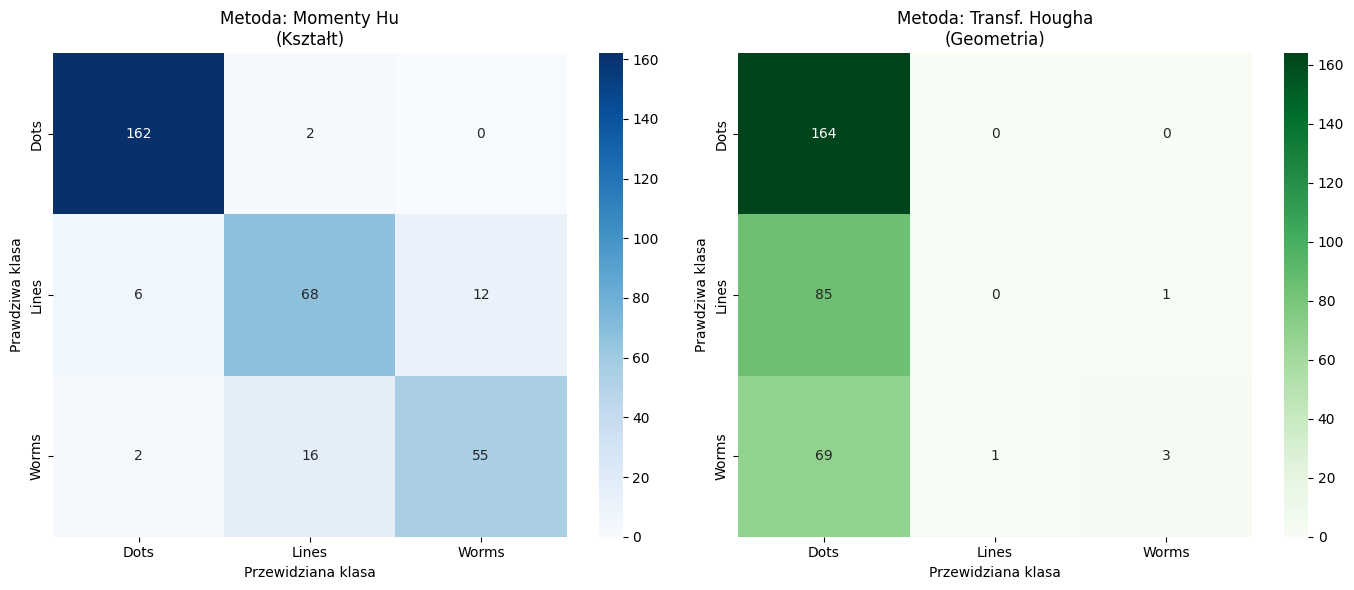

In [34]:
import cv2
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# KONFIGURACJA
BASE_DIR = "images"  # Upewnij się, że ta ścieżka jest poprawna
K_NEIGHBORS = 7

def get_image_filenames(base_dir):
    data = {}
    for cat in ['artefacts', 'dots', 'lines', 'worms']:
        path = os.path.join(base_dir, cat)
        if os.path.exists(path):
            data[cat] = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.bmp'))]
    return data

# --- FUNKCJE EKSTRAKCJI CECH ---

def get_hu_moments(img):
    # Binaryzacja
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    moments = cv2.moments(thresh)
    hu = cv2.HuMoments(moments).flatten()
    # Log transform - KLUCZOWE DLA KNN
    hu = -1 * np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return hu

def get_hough_features(img):
    # Preprocessing
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edges = cv2.Canny(thresh, 50, 150)

    # 1. Okręgi (Hough Circles)
    circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, dp=1.2, minDist=20,
                               param1=50, param2=30, minRadius=5, maxRadius=50)
    num_circles = len(circles[0]) if circles is not None else 0

    # 2. Linie (Hough Lines Probabilistic)
    lines = cv2.HoughLinesP(thresh, 1, np.pi/180, threshold=20, minLineLength=15, maxLineGap=10)

    num_lines = 0
    avg_len = 0
    line_density = 0

    if lines is not None:
        num_lines = len(lines)
        lengths = []
        for line in lines:
            x1, y1, x2, y2 = line[0]
            lengths.append(np.sqrt((x2-x1)**2 + (y2-y1)**2))
        avg_len = np.mean(lengths) if lengths else 0
        # Stosunek pikseli krawędziowych do wykrytych linii
        line_density = num_lines / (np.sum(edges > 0) / 255 + 1)

    # Wektor cech dla KNN: [Liczba Okręgów, Liczba Linii, Średnia Długość, Gęstość]
    return np.array([num_circles, num_lines, avg_len, line_density])

# --- FUNKCJA WIZUALIZACJI (Poprawione wcięcie) ---

def visualize_comparison(y_true_hu, preds_hu, y_true_hough, preds_hough, classes):
    """
    Rysuje dwie macierze pomyłek obok siebie dla łatwego porównania.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 1. Macierz dla Momentów Hu
    cm_hu = confusion_matrix(y_true_hu, preds_hu)
    sns.heatmap(cm_hu, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=classes, yticklabels=classes)
    axes[0].set_title('Metoda: Momenty Hu\n(Kształt)')
    axes[0].set_ylabel('Prawdziwa klasa')
    axes[0].set_xlabel('Przewidziana klasa')

    # 2. Macierz dla Transformacji Hougha
    cm_hough = confusion_matrix(y_true_hough, preds_hough)
    sns.heatmap(cm_hough, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=classes, yticklabels=classes)
    axes[1].set_title('Metoda: Transf. Hougha\n(Geometria)')
    axes[1].set_ylabel('Prawdziwa klasa')
    axes[1].set_xlabel('Przewidziana klasa')

    plt.tight_layout()
    plt.show()

# --- GŁÓWNA LOGIKA ---

def main():
    files = get_image_filenames(BASE_DIR)
    # Sprawdzenie czy znaleziono pliki
    total_files = sum([len(v) for k,v in files.items()])
    print(f"Znaleziono łącznie {total_files} plików: { {k: len(v) for k, v in files.items()} }")

    if total_files == 0:
        print("Błąd: Nie znaleziono obrazów. Sprawdź ścieżkę BASE_DIR.")
        return

    # 1. TRENOWANIE FILTRA ARTEFAKTÓW
    print("\n--- Trenowanie Filtra Artefaktów (Hu Moments + KNN) ---")
    X_filter, y_filter = [], []

    for f in files.get('artefacts', []):
        img = cv2.imread(f, 0)
        if img is not None:
            X_filter.append(get_hu_moments(img))
            y_filter.append(0)

    for cat in ['dots', 'lines', 'worms']:
        for f in files.get(cat, []):
            img = cv2.imread(f, 0)
            if img is not None:
                X_filter.append(get_hu_moments(img))
                y_filter.append(1)

    if not X_filter:
        print("Brak danych do filtra.")
        return

    scaler_filter = StandardScaler()
    X_filter = scaler_filter.fit_transform(X_filter)
    knn_filter = KNeighborsClassifier(n_neighbors=5)
    knn_filter.fit(X_filter, y_filter)
    print("Filtr gotowy.")

    # 2. PRZYGOTOWANIE DATASETU
    dataset = []
    for cat in ['dots', 'lines', 'worms']:
        for f in files.get(cat, []):
            dataset.append((f, cat))

    # 3. EKSPERYMENT PORÓWNAWCZY
    methods = ['Hu Moments', 'Hough Transform']
    results = {}  # Słownik do przechowywania wyników dla wykresu

    valid_labels_map = {'dots': 0, 'lines': 1, 'worms': 2}
    classes_names = ['Dots', 'Lines', 'Worms']

    for method in methods:
        print(f"\n=== Metoda: {method} ===")
        X_main, y_main = [], []

        accepted_count = 0
        rejected_count = 0

        for path, label_name in dataset:
            img = cv2.imread(path, 0)
            if img is None: continue

            # A. Filtracja
            feats_for_filter = get_hu_moments(img).reshape(1, -1)
            feats_for_filter = scaler_filter.transform(feats_for_filter)
            is_valid = knn_filter.predict(feats_for_filter)[0]

            if is_valid == 0:
                rejected_count += 1
                continue

            accepted_count += 1

            # B. Ekstrakcja właściwa
            if method == 'Hu Moments':
                features = get_hu_moments(img)
            else:
                features = get_hough_features(img)

            X_main.append(features)
            y_main.append(valid_labels_map[label_name])

        print(f"Filtr odrzucił {rejected_count}, zaakceptował {accepted_count}.")

        if len(X_main) < 10:
            print("Za mało danych do treningu.")
            continue

        # Podział i Skalowanie
        X_train, X_test, y_train, y_test = train_test_split(
            np.array(X_main), np.array(y_main), test_size=0.3, random_state=42
        )

        scaler_main = StandardScaler()
        X_train = scaler_main.fit_transform(X_train)
        X_test = scaler_main.transform(X_test)

        # Trening i Predykcja
        clf = KNeighborsClassifier(n_neighbors=K_NEIGHBORS)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        # Zapisanie wyników do wizualizacji
        acc = accuracy_score(y_test, preds)
        print(f"Accuracy: {acc:.4f}")
        results[method] = (y_test, preds)

    # 4. WYWOŁANIE WIZUALIZACJI (Jeśli obie metody zadziałały)
    if 'Hu Moments' in results and 'Hough Transform' in results:
        print("\nGenerowanie wykresu porównawczego...")
        visualize_comparison(
            results['Hu Moments'][0], results['Hu Moments'][1],
            results['Hough Transform'][0], results['Hough Transform'][1],
            classes_names
        )
    else:
        print("Nie udało się zebrać wyników dla obu metod, pomijam wykres.")

if __name__ == "__main__":
    main()

Zastosowany filtr artefaktów oparty na Momentach Hu skutecznie zidentyfikował i odrzucił 158 obrazów, które zostały sklasyfikowane jako artefakty.

Metoda oparta na Momentach Hu wykazała znacznie wyższą skuteczność, osiągając dokładność na poziomie 0.8824 w klasyfikacji obiektów po odrzuceniu artefaktów. Transformacja Hougha osiągnęła znacznie niższą dokładność, wynoszącą 0.5170. Sugeruje to, że dla tego zestawu danych, cechy geometryczne wykrywane przez Transformację Hougha są mniej opisowe i mniej skuteczne niż cechy oparte na kształcie